# 통계청 인공지능 경진대회 - 산업분류 예측하기

# 1.라이브러리 및 함수 생성

In [ ]:
"""
import logging

#로그 생성
logger = logging.getLogger()

#로그의 출력 기준 설정
logger.setLevel(logging.INFO)

#log 출력 형식
formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')

#log 출력
stream_handler = logging.StreamHandler()
stream_handler.setFormatter(formatter)
logger.addHandler(stream_handler)

#log를 파일에 출력
file_handler = logging.FileHandler('my.log')
file_handler.setFormatter(formatter)
logger.addHandler(file_handler)
"""

"\nimport logging\n\n#로그 생성\nlogger = logging.getLogger()\n\n#로그의 출력 기준 설정\nlogger.setLevel(logging.INFO)\n\n#log 출력 형식\nformatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')\n\n#log 출력\nstream_handler = logging.StreamHandler()\nstream_handler.setFormatter(formatter)\nlogger.addHandler(stream_handler)\n\n#log를 파일에 출력\nfile_handler = logging.FileHandler('my.log')\nfile_handler.setFormatter(formatter)\nlogger.addHandler(file_handler)\n"

In [ ]:
###라이브러리
import re
import pandas as pd
import numpy as np
 
import seaborn as sns
import matplotlib.pyplot as plt
 
from sklearn.feature_extraction.text import CountVectorizer
from konlpy.tag import Mecab 
mecab = Mecab(dicpath=r"C:\mecab\mecab-ko-dic")
 
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
 
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
 
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense, Dropout, Conv1D, MaxPooling1D
from keras.callbacks import EarlyStopping, ModelCheckpoint

# 두글자 이상의 명사추출 함수
def extractTwo(readData):
    noun = mecab.nouns(readData)
    noun_rt = []
    for i,v in enumerate(noun):
        if len(v)>1:
            noun_rt.append(v)
    return noun_rt

# 2.데이터 불러오기

In [ ]:
train = pd.read_csv('1. 실습용자료.txt',sep='|',encoding='EUC-KR')
Cat = pd.read_excel('한국표준산업분류(10차)_국문.xlsx',header=2)

# 3. 데이터 전처리

In [ ]:
# 분류카테고리데이터
Cat = Cat[['코드','항목명','코드.1','항목명.1','코드.2','항목명.2']]
Cat = Cat.rename(columns ={'코드':'digit_1','코드.1':'digit_2','코드.2':'digit_3','항목명':'digit_1_name','항목명.1':'digit_2_name','항목명.2':'digit_3_name'})
Cat = Cat.dropna(how='all')
Cat = Cat.fillna(method='ffill')
Cat

,digit_1,digit_1_name,digit_2,digit_2_name,digit_3,digit_3_name
0,A,"농업, 임업 및 어업(01~03)",1.0,농업,11.0,작물 재배업
10,A,"농업, 임업 및 어업(01~03)",1.0,농업,12.0,축산업
17,A,"농업, 임업 및 어업(01~03)",1.0,농업,13.0,작물재배 및 축산 복합농업
18,A,"농업, 임업 및 어업(01~03)",1.0,농업,14.0,작물재배 및 축산 관련 서비스업
21,A,"농업, 임업 및 어업(01~03)",1.0,농업,15.0,수렵 및 관련 서비스업
...,...,...,...,...,...,...
1181,S,"협회 및 단체, 수리 및 기타 개인 서비스업(94~96)",96.0,기타 개인 서비스업,969.0,그 외 기타 개인 서비스업
1192,T,가구 내 고용활동 및 달리 분류되지 않은 자가 소비 생산활동(97~98),97.0,가구 내 고용활동,970.0,가구 내 고용활동
1193,T,가구 내 고용활동 및 달리 분류되지 않은 자가 소비 생산활동(97~98),98.0,달리 분류되지 않은 자가 소비를 위한 가구의 재화 및 서비스 생산활동,981.0,자가 소비를 위한 가사 생산 활동
1194,T,가구 내 고용활동 및 달리 분류되지 않은 자가 소비 생산활동(97~98),98.0,달리 분류되지 않은 자가 소비를 위한 가구의 재화 및 서비스 생산활동,982.0,자가 소비를 위한 가사 서비스 활동


In [ ]:
#전체데이터
read_data = pd.merge(train,Cat, how="left", on=['digit_1','digit_2','digit_3'])
read_data

,AI_id,digit_1,digit_2,digit_3,text_obj,text_mthd,text_deal,digit_1_name,digit_2_name,digit_3_name
0,id_0000001,S,95,952,카센터에서,자동차부분정비,타이어오일교환,"협회 및 단체, 수리 및 기타 개인 서비스업(94~96)",개인 및 소비용품 수리업,자동차 및 모터사이클 수리업
1,id_0000002,G,47,472,상점내에서,일반인을 대상으로,채소.과일판매,도매 및 소매업(45~47),소매업; 자동차 제외,음ㆍ식료품 및 담배 소매업
2,id_0000003,G,46,467,절단하여사업체에도매,공업용고무를가지고,합성고무도매,도매 및 소매업(45~47),도매 및 상품 중개업,기타 전문 도매업
3,id_0000004,G,47,475,영업점에서,일반소비자에게,열쇠잠금장치,도매 및 소매업(45~47),소매업; 자동차 제외,기타 생활용품 소매업
4,id_0000005,Q,87,872,어린이집,보호자의 위탁을 받아,취학전아동보육,보건업 및 사회복지 서비스업(86~87),사회복지 서비스업,비거주 복지시설 운영업
...,...,...,...,...,...,...,...,...,...,...
999995,id_0999996,C,13,134,제품입고,워싱,청바지워싱,제조업(10~34),섬유제품 제조업; 의복 제외,"섬유제품 염색, 정리 및 마무리 가공업"
999996,id_0999997,F,42,424,현장에서,고객의요청에의해,실내인테리어,건설업(41~42),전문직별 공사업,실내건축 및 건축마무리 공사업
999997,id_0999998,G,47,474,영업점에서,일반소비자에게,여성의류 판매,도매 및 소매업(45~47),소매업; 자동차 제외,"섬유, 의복, 신발 및 가죽제품 소매업"
999998,id_0999999,P,85,856,사업장에서,일반고객을대상으로,필라테스,교육 서비스업(85),교육 서비스업,기타 교육기관


# 4.모델학습

## <대분류>

### a. 데이터전처리

In [ ]:
# text_obj, text_mthd, text_deal을 text 하나로 만들기
read_data['text'] = read_data["text_obj"].map(str)+ " " + read_data["text_mthd"].map(str)+ " " + read_data["text_deal"].map(str)

In [ ]:
# 필요한 데이터 읽어오기
new_data = read_data.loc[:, ["digit_1_name", "text"]]
# 카테고리 정수 인코딩
category_list_1 = pd.factorize(new_data['digit_1_name'])[1]
new_data['category'] = pd.factorize(new_data['digit_1_name'])[0]

In [ ]:
# 정규표현식 사용하여 문자열이 아닌 데이터(^\w)는 공백처리
new_data['text'] = new_data['text'].str.replace("[^\w]", " ")

<ipython-input-8-e88171c515bd>:2: FutureWarning: The default value of regex will change from True to False in a future version.
  new_data['text'] = new_data['text'].str.replace("[^\w]", " ")


In [ ]:
# train과 test 데이터로 split하면서 shuffle 적용
new_train, new_test, y_train, y_test = train_test_split(new_data['text'], new_data['category'], test_size=0.2, shuffle=True, random_state=23)

# y값을 원핫벡터로 변환
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [ ]:
# 토큰화
stopwords = []
 
X_train = []
for stc in new_train:
    token = []
    words = extractTwo(stc)
    for word in words:
        if word not in stopwords:
            token.append(word)
    X_train.append(token)

X_test = []
for stc in new_test:
    token = []
    words = extractTwo(stc)
    for word in words:
        if word not in stopwords:
            token.append(word)
    X_test.append(token)

In [ ]:
# 토큰화와 시퀀스의 형태로 변환
tokenizer1 = Tokenizer(25000)
tokenizer1.fit_on_texts(X_train)
 
X_train = tokenizer1.texts_to_sequences(X_train)
X_test = tokenizer1.texts_to_sequences(X_test)

In [ ]:
max_len_1 = max(len(item) for item in X_train)
X_train = pad_sequences(X_train, maxlen=max_len_1)
X_test = pad_sequences(X_test, maxlen=max_len_1)
print("X_train:", X_train.shape)

X_train: (800000, 24)


### b.모델 생성 및 학습

In [ ]:
# 모델생성
model1 = Sequential()
model1.add(Embedding(25000, 128))
model1.add(Conv1D(filters=32, kernel_size=3, padding='same', activation='tanh'))
model1.add(MaxPooling1D(pool_size=2))
model1.add(LSTM(128))
model1.add(Dropout(0.2))
model1.add(Dense(19, activation='softmax'))

In [ ]:
# 모델컴파일
model1.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['acc'])
 
#early stopping
es = EarlyStopping(monitor='val_loss', patience=0,verbose=0,mode='min')
#모델저장
mc = ModelCheckpoint('model1.h5', monitor='val_loss', mode='min', save_best_only=True)

# 모델훈련
history1 = model1.fit(X_train, y_train, validation_data=(X_test, y_test), batch_size=64, epochs=4, callbacks=[es,mc])

Epoch 1/4
12500/12500 [==============================] - 475s 38ms/step - loss: 0.1573 - acc: 0.9566 - val_loss: 0.1052 - val_acc: 0.9703
Epoch 2/4
12500/12500 [==============================] - 480s 38ms/step - loss: 0.0959 - acc: 0.9727 - val_loss: 0.0981 - val_acc: 0.9718


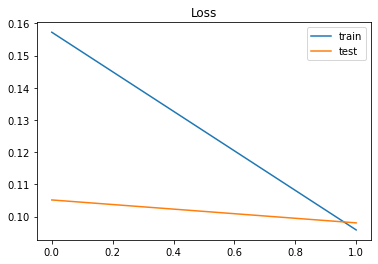

In [ ]:
# 손실 그래프
plt.title('Loss')
plt.plot(history1.history['loss'], label='train')
plt.plot(history1.history['val_loss'], label='test')
plt.legend()
plt.show();

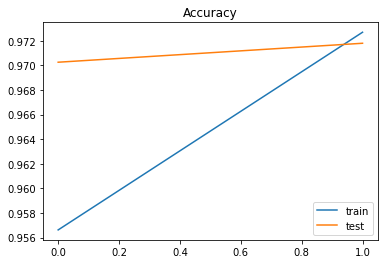

In [ ]:
# 정확도 그래프
plt.title('Accuracy')
plt.plot(history1.history['acc'], label='train')
plt.plot(history1.history['val_acc'], label='test')
plt.legend()
plt.show();

## <중분류>

### a.데이터 전처리

In [ ]:
# text_obj, text_mthd, text_deal을 text 하나로 만들기
read_data['s_digit1'] = read_data["text_obj"].map(str)+ " " + read_data["text_mthd"].map(str)+ " " + read_data["text_deal"].map(str)+ " " + read_data['digit_1_name'].map(str)

In [ ]:
# 대분류에 필요한 데이터 읽어오기
new_data2 = read_data.loc[:, ['digit_2_name', 's_digit1']]
 
# y값을 카테고리 정수로 인코딩
category_list_2 = pd.factorize(new_data2['digit_2_name'])[1]
new_data2['category'] = pd.factorize(new_data2['digit_2_name'])[0]

In [ ]:
# 정규표현식 사용하여 문자열이 아닌 데이터(^\w)는 공백처리
new_data2['s_digit1'] = new_data2['s_digit1'].str.replace("[^\w]", " ")

<ipython-input-19-6cc224ec321b>:2: FutureWarning: The default value of regex will change from True to False in a future version.
  new_data2['s_digit1'] = new_data2['s_digit1'].str.replace("[^\w]", " ")


In [ ]:
# train과 test 데이터로 split하면서 shuffle 적용
new_train, new_test, y_train, y_test = train_test_split(new_data2['s_digit1'], new_data2['category'], test_size=0.2, shuffle=True, random_state=23)
 
# y값을 원핫벡터로 변환
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [ ]:
# 토큰화
stopwords = []
 
X_train = []
for stc in new_train:
    token = []
    words = extractTwo(stc)
    for word in words:
        if word not in stopwords:
            token.append(word)
    X_train.append(token)

X_test = []
for stc in new_test:
    token = []
    words = extractTwo(stc)
    for word in words:
        if word not in stopwords:
            token.append(word)
    X_test.append(token)

In [ ]:
# 토큰화와 시퀀스의 형태로 변환
tokenizer2 = Tokenizer(25000)
tokenizer2.fit_on_texts(X_train)
 
X_train = tokenizer2.texts_to_sequences(X_train)
X_test = tokenizer2.texts_to_sequences(X_test)

In [ ]:
# 서로 다른 개수의 단어로 이루어진 문장을 같은 길이로 만들어주기 위해 패딩 진행
max_len_2 = max(len(item) for item in X_train)
X_train = pad_sequences(X_train, maxlen=max_len_2)
X_test = pad_sequences(X_test, maxlen=max_len_2)
print("X_train:", X_train.shape)

X_train: (800000, 31)


### b. 모델 생성 및 학습

In [ ]:
# 모델생성
model2 = Sequential()
model2.add(Embedding(25000, 128))
model2.add(Conv1D(filters=32, kernel_size=3, padding='same', activation='tanh'))
model2.add(MaxPooling1D(pool_size=2))
model2.add(LSTM(128))
model2.add(Dropout(0.2))
model2.add(Dense(74, activation='softmax'))

In [ ]:
# 모델컴파일
model2.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['acc'])
 
# early stopping
es = EarlyStopping(monitor='val_loss', patience=0,verbose=0,mode='min')
# 모델저장
mc = ModelCheckpoint('model2.h5', monitor='val_loss', mode='min', save_best_only=True)

# 모델훈련
history2 = model2.fit(X_train, y_train, validation_data=(X_test, y_test), batch_size=64, epochs=4, callbacks=[es,mc])

Epoch 1/4
12500/12500 [==============================] - 520s 42ms/step - loss: 0.2245 - acc: 0.9354 - val_loss: 0.1433 - val_acc: 0.9557
Epoch 2/4
12500/12500 [==============================] - 513s 41ms/step - loss: 0.1292 - acc: 0.9601 - val_loss: 0.1341 - val_acc: 0.9586


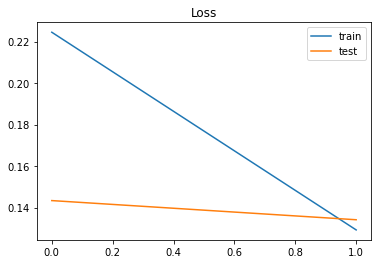

In [ ]:
# 손실 그래프
plt.title('Loss')
plt.plot(history2.history['loss'], label='train')
plt.plot(history2.history['val_loss'], label='test')
plt.legend()
plt.show();

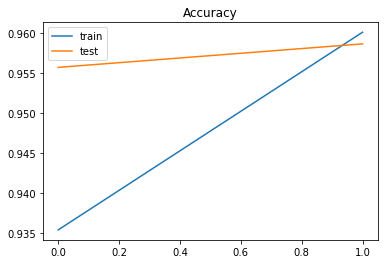

In [ ]:
# 정확도 그래프
plt.title('Accuracy')
plt.plot(history2.history['acc'], label='train')
plt.plot(history2.history['val_acc'], label='test')
plt.legend()
plt.show();

## <소분류>

### a. 데이터전처리

In [ ]:
# text_obj, text_mthd, text_deal, digit_3_name을 text 하나로 만들기
read_data['s_digit2'] = read_data["text_obj"].map(str)+ " " + read_data["text_mthd"].map(str)+ " " + read_data["text_deal"].map(str)+ " " + read_data['digit_1_name'].map(str)+ " " + read_data["digit_2_name"].map(str)

In [ ]:
# 대분류에 필요한 데이터 읽어오기
new_data3 = read_data.loc[:, ['digit_3_name', 's_digit2']]
 
# y값을 카테고리 정수로 인코딩
category_list_3 = pd.factorize(new_data3['digit_3_name'])[1]
new_data3['category'] = pd.factorize(new_data3['digit_3_name'])[0]

In [ ]:
# 정규표현식 사용하여 문자열이 아닌 데이터(^\w)는 공백처리
new_data3['s_digit2'] = new_data3['s_digit2'].str.replace("[^\w]", " ")

<ipython-input-30-b0d43292ee9b>:2: FutureWarning: The default value of regex will change from True to False in a future version.
  new_data3['s_digit2'] = new_data3['s_digit2'].str.replace("[^\w]", " ")


In [ ]:
# train과 test 데이터로 split하면서 shuffle 적용
new_train, new_test, y_train, y_test = train_test_split(new_data3['s_digit2'], new_data3['category'], test_size=0.2, shuffle=True, random_state=23)
 
# y값을 원핫벡터로 변환
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [ ]:
# 토큰화
stopwords = [] #미지정
 
X_train = []
for stc in new_train:
    token = []
    words = extractTwo(stc)
    for word in words:
        if word not in stopwords:
            token.append(word)
    X_train.append(token)

X_test = []
for stc in new_test:
    token = []
    words = extractTwo(stc)
    for word in words:
        if word not in stopwords:
            token.append(word)
    X_test.append(token)

In [ ]:
# 토큰화와 시퀀스의 형태로 변환
tokenizer3 = Tokenizer(25000)
tokenizer3.fit_on_texts(X_train)
 
X_train = tokenizer3.texts_to_sequences(X_train)
X_test = tokenizer3.texts_to_sequences(X_test)

In [ ]:
# 서로 다른 개수의 단어로 이루어진 문장을 같은 길이로 만들어주기 위해 패딩 진행
max_len_3 = max(len(item) for item in X_train)
X_train = pad_sequences(X_train, maxlen=max_len_3)
X_test = pad_sequences(X_test, maxlen=max_len_3)
print("X_train:", X_train.shape)

X_train: (800000, 34)


### b. 모델 생성 및 학습

In [ ]:
# 모델생성
model3 = Sequential()
model3.add(Embedding(25000, 128))
model3.add(Conv1D(filters=32, kernel_size=3, padding='same', activation='tanh'))
model3.add(MaxPooling1D(pool_size=2))
model3.add(LSTM(128))
model3.add(Dropout(0.2))
model3.add(Dense(225, activation='softmax'))

In [ ]:
# 모델학습
model3.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['acc'])
 
#early stopping
es = EarlyStopping(monitor='val_loss', patience=0,verbose=0,mode='min')
#모델저장
mc = ModelCheckpoint('model3.h5', monitor='val_loss', mode='min', save_best_only=True)

# 모델훈련
history3 = model3.fit(X_train, y_train, validation_data=(X_test, y_test), batch_size=64, epochs=4, callbacks=[es,mc])

Epoch 1/4
12500/12500 [==============================] - 537s 43ms/step - loss: 0.3432 - acc: 0.9032 - val_loss: 0.1673 - val_acc: 0.9472
Epoch 2/4
12500/12500 [==============================] - 532s 43ms/step - loss: 0.1552 - acc: 0.9522 - val_loss: 0.1531 - val_acc: 0.9527


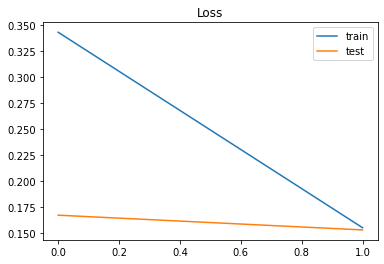

In [ ]:
# 손실 그래프
plt.title('Loss')
plt.plot(history3.history['loss'], label='train')
plt.plot(history3.history['val_loss'], label='test')
plt.legend()
plt.show();

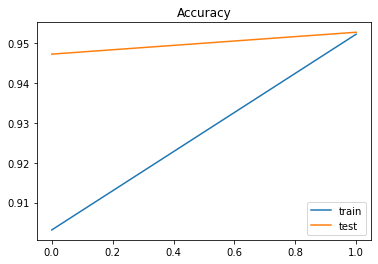

In [ ]:
# 정확도 그래프
plt.title('Accuracy')
plt.plot(history3.history['acc'], label='train')
plt.plot(history3.history['val_acc'], label='test')
plt.legend()
plt.show();

# 5. 결과출력

### a. 데이터불러오기

In [ ]:
test = pd.read_csv('2. 모델개발용자료.txt',sep='|',encoding='EUC-KR')
test = test.drop(columns=['digit_1','digit_2','digit_3'])

### b. 예측값

<대분류>

In [ ]:
test['text'] = test["text_obj"].map(str)+ " " + test["text_mthd"].map(str)+ " " + test["text_deal"].map(str)

In [ ]:
for i in test.index:
    token_stc = extractTwo(test['text'][i])
    encode_stc = tokenizer1.texts_to_sequences([token_stc])
    pad_stc = pad_sequences(encode_stc, maxlen=max_len_1)
    score = model1.predict(pad_stc)
    test.at[i,'digit_1_name'] = category_list_1[score.argmax()]

In [ ]:
test = test.drop(columns=['text'])

In [ ]:
test.to_csv("mid1_predict.csv",sep='|',encoding='EUC-KR',index=False)
test

,AI_id,text_obj,text_mthd,text_deal,digit_1_name
0,id_000001,치킨전문점에서,고객의주문에의해,치킨판매,숙박 및 음식점업(55~56)
1,id_000002,산업공구,다른 소매업자에게,철물 수공구,도매 및 소매업(45~47)
2,id_000003,절에서,신도을 대상으로,불교단체운영,"협회 및 단체, 수리 및 기타 개인 서비스업(94~96)"
3,id_000004,영업장에서,고객요구로,자동차튜닝,"협회 및 단체, 수리 및 기타 개인 서비스업(94~96)"
4,id_000005,실내포장마차에서,접객시설을 갖추고,"소주,맥주제공",숙박 및 음식점업(55~56)
...,...,...,...,...,...
99995,id_099996,사업장에서,일반인대상으로,버섯농장,도매 및 소매업(45~47)
99996,id_099997,한의원에서,외래환자위주고,치료,보건업 및 사회복지 서비스업(86~87)
99997,id_099998,일반점포에서,소비자에게,그림판매,도매 및 소매업(45~47)
99998,id_099999,사업장에서,일반인.학생대상으로,학습공간제공,"예술, 스포츠 및 여가관련 서비스업(90~91)"


<중분류>

In [ ]:
test['s_digit1'] = test["text_obj"].map(str)+ " " + test["text_mthd"].map(str)+ " " + test["text_deal"].map(str)+ " " + test['digit_1_name'].map(str)

In [ ]:
for i in test.index:
    token_stc = extractTwo(test['s_digit1'][i])
    encode_stc = tokenizer2.texts_to_sequences([token_stc])
    pad_stc = pad_sequences(encode_stc, maxlen=max_len_2)
    score = model2.predict(pad_stc)
    test.at[i,'digit_2_name'] = category_list_2[score.argmax()]

In [ ]:
test = test.drop(columns=['s_digit1'])

In [ ]:
test.to_csv("mid2_predict.csv",sep='|',encoding='EUC-KR',index=False)
test

,AI_id,text_obj,text_mthd,text_deal,digit_1_name,digit_2_name
0,id_000001,치킨전문점에서,고객의주문에의해,치킨판매,숙박 및 음식점업(55~56),음식점 및 주점업
1,id_000002,산업공구,다른 소매업자에게,철물 수공구,도매 및 소매업(45~47),도매 및 상품 중개업
2,id_000003,절에서,신도을 대상으로,불교단체운영,"협회 및 단체, 수리 및 기타 개인 서비스업(94~96)",협회 및 단체
3,id_000004,영업장에서,고객요구로,자동차튜닝,"협회 및 단체, 수리 및 기타 개인 서비스업(94~96)",개인 및 소비용품 수리업
4,id_000005,실내포장마차에서,접객시설을 갖추고,"소주,맥주제공",숙박 및 음식점업(55~56),음식점 및 주점업
...,...,...,...,...,...,...
99995,id_099996,사업장에서,일반인대상으로,버섯농장,도매 및 소매업(45~47),소매업; 자동차 제외
99996,id_099997,한의원에서,외래환자위주고,치료,보건업 및 사회복지 서비스업(86~87),보건업
99997,id_099998,일반점포에서,소비자에게,그림판매,도매 및 소매업(45~47),소매업; 자동차 제외
99998,id_099999,사업장에서,일반인.학생대상으로,학습공간제공,"예술, 스포츠 및 여가관련 서비스업(90~91)","창작, 예술 및 여가관련 서비스업"


<소분류>

In [ ]:
test['s_digit2'] = test["text_obj"].map(str)+ " " + test["text_mthd"].map(str)+ " " + test["text_deal"].map(str)+ " " + test['digit_1_name'].map(str)+ " " + test["digit_2_name"].map(str)

In [ ]:
for i in test.index:
    token_stc = extractTwo(test['s_digit2'][i])
    encode_stc = tokenizer3.texts_to_sequences([token_stc])
    pad_stc = pad_sequences(encode_stc, maxlen=max_len_3)
    score = model3.predict(pad_stc)
    test.at[i,'digit_3_name'] = category_list_3[score.argmax()]

In [ ]:
test = test.drop(columns=['s_digit2'])

In [ ]:
test.to_csv("mid3_predict.csv",sep='|',encoding='EUC-KR',index=False)
test

,AI_id,text_obj,text_mthd,text_deal,digit_1_name,digit_2_name,digit_3_name
0,id_000001,치킨전문점에서,고객의주문에의해,치킨판매,숙박 및 음식점업(55~56),음식점 및 주점업,음식점업
1,id_000002,산업공구,다른 소매업자에게,철물 수공구,도매 및 소매업(45~47),도매 및 상품 중개업,"건축 자재, 철물 및 난방장치 도매업"
2,id_000003,절에서,신도을 대상으로,불교단체운영,"협회 및 단체, 수리 및 기타 개인 서비스업(94~96)",협회 및 단체,기타 협회 및 단체
3,id_000004,영업장에서,고객요구로,자동차튜닝,"협회 및 단체, 수리 및 기타 개인 서비스업(94~96)",개인 및 소비용품 수리업,자동차 및 모터사이클 수리업
4,id_000005,실내포장마차에서,접객시설을 갖추고,"소주,맥주제공",숙박 및 음식점업(55~56),음식점 및 주점업,주점 및 비알코올 음료점업
...,...,...,...,...,...,...,...
99995,id_099996,사업장에서,일반인대상으로,버섯농장,도매 및 소매업(45~47),소매업; 자동차 제외,음ㆍ식료품 및 담배 소매업
99996,id_099997,한의원에서,외래환자위주고,치료,보건업 및 사회복지 서비스업(86~87),보건업,의원
99997,id_099998,일반점포에서,소비자에게,그림판매,도매 및 소매업(45~47),소매업; 자동차 제외,기타 상품 전문 소매업
99998,id_099999,사업장에서,일반인.학생대상으로,학습공간제공,"예술, 스포츠 및 여가관련 서비스업(90~91)","창작, 예술 및 여가관련 서비스업","도서관, 사적지 및 유사 여가관련 서비스업"


### c. 최종결과 및 제출파일저장

In [ ]:
Cat1 = Cat[['digit_1','digit_1_name']].drop_duplicates()
Cat2 = Cat[['digit_2','digit_2_name']].drop_duplicates()
Cat3 = Cat[['digit_3','digit_3_name']].drop_duplicates()

final_predict = pd.merge(test,Cat1,how='left')
final_predict = pd.merge(final_predict,Cat2,how='left')
final_predict = pd.merge(final_predict,Cat3,how='left')

In [ ]:
final_predict=final_predict[['AI_id','digit_1','digit_2','digit_3','text_obj','text_mthd','text_deal']]
final_predict

,AI_id,digit_1,digit_2,digit_3,text_obj,text_mthd,text_deal
0,id_000001,I,56.0,561.0,치킨전문점에서,고객의주문에의해,치킨판매
1,id_000002,G,46.0,466.0,산업공구,다른 소매업자에게,철물 수공구
2,id_000003,S,94.0,949.0,절에서,신도을 대상으로,불교단체운영
3,id_000004,S,95.0,952.0,영업장에서,고객요구로,자동차튜닝
4,id_000005,I,56.0,562.0,실내포장마차에서,접객시설을 갖추고,"소주,맥주제공"
...,...,...,...,...,...,...,...
99995,id_099996,G,47.0,472.0,사업장에서,일반인대상으로,버섯농장
99996,id_099997,Q,86.0,862.0,한의원에서,외래환자위주고,치료
99997,id_099998,G,47.0,478.0,일반점포에서,소비자에게,그림판매
99998,id_099999,R,90.0,902.0,사업장에서,일반인.학생대상으로,학습공간제공


In [ ]:
# 결과파일 저장
final_predict.to_csv("산업분류 예측값.csv",sep='|',encoding='EUC-KR',index=False)